# 03 — Naive Bayes (GaussianNB) — Baseline + Tuning

Bu notebook, ekip şablonunun Naive Bayes için doldurulmuş halidir.

- Model: `GaussianNB`
- Hedef metrik: `f1_macro`
- Tuning: `var_smoothing` parametresi (`GridSearchCV`, `cv=5`)

## 1. Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

RANDOM_STATE = 42

X_train = pd.read_csv('../data/X_train_final.csv')
X_test  = pd.read_csv('../data/X_test_final.csv')
y_train = pd.read_csv('../data/y_train_final.csv').iloc[:, 0]
y_test  = pd.read_csv('../data/y_test_final.csv').iloc[:, 0]

siniflar = ['Ekonomik', 'Orta', 'Yüksek', 'Premium']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'\nSınıf dağılımı (train):')
print(y_train.value_counts(normalize=True).round(3).to_string())

X_train: (2739, 74), X_test: (685, 74)

Sınıf dağılımı (train):
Fiyat_Sinifi
Ekonomik    0.253
Yüksek      0.250
Premium     0.250
Orta        0.248


## 2. Baseline — Default Parametrelerle

Algoritmanı **hyperparameter tuning yapmadan**, sklearn'in varsayılan ayarlarıyla çalıştır. Bu "zemin skor".

**Yapacakların:**
1. `>>> import <<<` satırını aç (kendi algoritmanın import'u)
2. `>>> baseline_model = ... <<<` satırına kendi sınıfını yaz (örn. `KNeighborsClassifier()`)
3. Geri kalan kod aynen çalışır

In [2]:
from sklearn.naive_bayes import GaussianNB

# Baseline model — default parametreler
baseline_model = GaussianNB()

# Eğit + tahmin et (HERKES AYNI)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# Metrikleri yazdır (HERKES AYNI)
print('=== BASELINE — Default Parametreler ===\n')
print(f'Accuracy : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'F1 macro : {f1_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_base, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=siniflar))

=== BASELINE — Default Parametreler ===

Accuracy : 0.5518
F1 macro : 0.5156
Precision: 0.6272
Recall   : 0.5540

Classification Report:
              precision    recall  f1-score   support

    Ekonomik       0.74      0.18      0.29       173
        Orta       0.39      0.82      0.53       169
      Yüksek       0.75      0.90      0.82       171
     Premium       0.62      0.32      0.42       172

    accuracy                           0.55       685
   macro avg       0.63      0.55      0.52       685
weighted avg       0.63      0.55      0.51       685



## 3. Tuning — GridSearchCV ile Optimal Parametre Arama

**Yapacakların:**
1. `docs/TUNING_REHBERI.md`'de **kendi algoritmana ait bölümü** oku — hangi parametreleri tune etmen gerektiği yazıyor
2. **Her parametre için kendin uygun değerler bul** — sklearn dokümanı, ders slaytları
3. Aşağıdaki `param_grid = {...}` içine kendi seçtiğin değerleri yaz
4. Çalıştır (1-10 dakika)

**Bölüm 5'te yazacağın yorumda mutlaka anlat:** Niçin bu değerleri seçtin? Algoritmanı tanıdığın için ne tür değerlerin işe yarayacağını biliyordun.

**Sabit ayarlar (değiştirme):** `cv=5` (5-fold cross-validation), `scoring='f1_macro'`.

In [3]:
# GaussianNB için temel tuning parametresi: var_smoothing
param_grid = {
    'var_smoothing': np.logspace(-12, -7, 12)
}

# GridSearchCV (HERKES AYNI — değiştirme)
grid = GridSearchCV(
    baseline_model,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f'En iyi parametreler : {grid.best_params_}')
print(f'CV F1-macro skoru   : {grid.best_score_:.4f}')

# Optimize edilmiş model ile tahmin
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print('\n=== TUNED — Optimal Parametreler ===\n')
print(f'Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'F1 macro : {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_tuned, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=siniflar))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
En iyi parametreler : {'var_smoothing': np.float64(1e-07)}
CV F1-macro skoru   : 0.5440

=== TUNED — Optimal Parametreler ===

Accuracy : 0.5708
F1 macro : 0.5432
Precision: 0.6285
Recall   : 0.5727

Classification Report:
              precision    recall  f1-score   support

    Ekonomik       0.71      0.20      0.32       173
        Orta       0.41      0.78      0.54       169
      Yüksek       0.77      0.90      0.83       171
     Premium       0.62      0.41      0.49       172

    accuracy                           0.57       685
   macro avg       0.63      0.57      0.54       685
weighted avg       0.63      0.57      0.54       685



## 4. Karşılaştırma — Baseline vs Tuned (HERKES AYNI)

In [4]:
# Tablo: baseline vs tuned
karsilastirma = pd.DataFrame({
    'Metrik': ['Accuracy', 'F1-macro', 'Precision (macro)', 'Recall (macro)'],
    'Baseline': [
        accuracy_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base, average='macro'),
        precision_score(y_test, y_pred_base, average='macro'),
        recall_score(y_test, y_pred_base, average='macro'),
    ],
    'Tuned': [
        accuracy_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned, average='macro'),
        precision_score(y_test, y_pred_tuned, average='macro'),
        recall_score(y_test, y_pred_tuned, average='macro'),
    ],
})
karsilastirma['Δ (iyileşme)'] = (karsilastirma['Tuned'] - karsilastirma['Baseline']).round(4)
karsilastirma[['Baseline', 'Tuned']] = karsilastirma[['Baseline', 'Tuned']].round(4)
print('Baseline vs Tuned karşılaştırma:\n')
print(karsilastirma.to_string(index=False))

Baseline vs Tuned karşılaştırma:

           Metrik  Baseline  Tuned  Δ (iyileşme)
         Accuracy    0.5518 0.5708        0.0190
         F1-macro    0.5156 0.5432        0.0276
Precision (macro)    0.6272 0.6285        0.0014
   Recall (macro)    0.5540 0.5727        0.0187


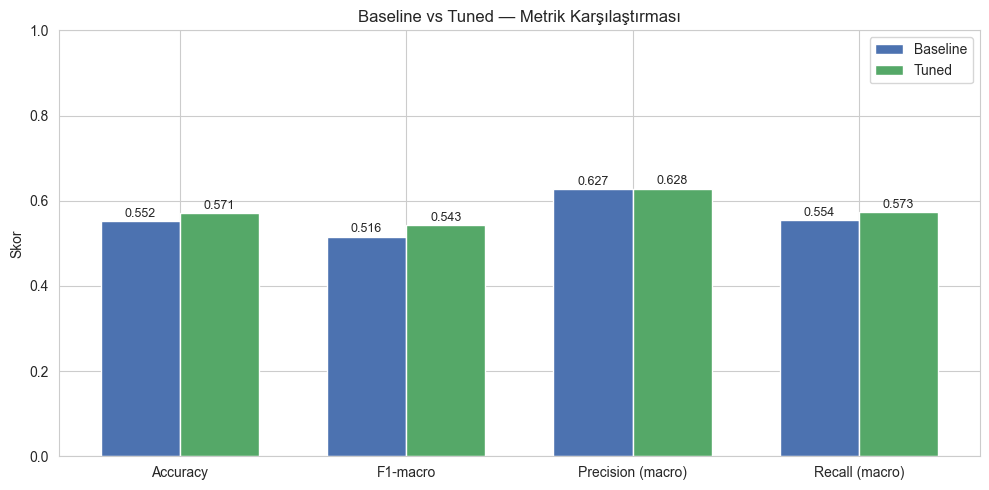

In [5]:
# Bar chart — metrik bazlı baseline vs tuned
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(karsilastirma))
width = 0.35
ax.bar(x - width/2, karsilastirma['Baseline'], width, label='Baseline', color='#4c72b0')
ax.bar(x + width/2, karsilastirma['Tuned'],    width, label='Tuned',    color='#55a868')
ax.set_xticks(x)
ax.set_xticklabels(karsilastirma['Metrik'])
ax.set_ylabel('Skor')
ax.set_title('Baseline vs Tuned — Metrik Karşılaştırması')
ax.legend()
ax.set_ylim(0, 1)
for i, (b, t) in enumerate(zip(karsilastirma['Baseline'], karsilastirma['Tuned'])):
    ax.text(i - width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

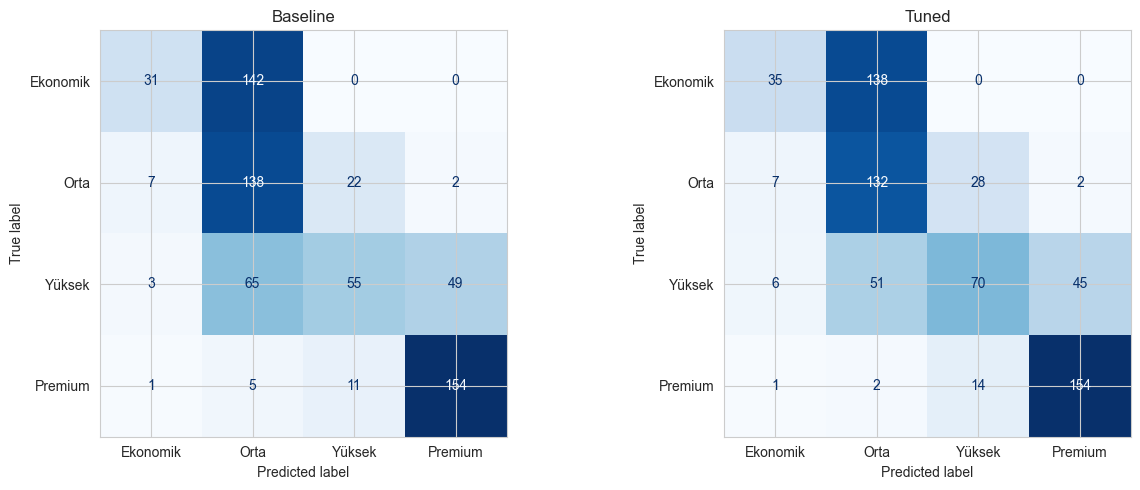

In [6]:
# İki confusion matrix yan yana
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, baslik in zip(axes, [y_pred_base, y_pred_tuned], ['Baseline', 'Tuned']):
    cm = confusion_matrix(y_test, y_pred, labels=siniflar)
    disp = ConfusionMatrixDisplay(cm, display_labels=siniflar)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(baslik)
plt.tight_layout()
plt.show()

In [7]:
# Feature importance (sadece ağaç-tabanlı modeller için)
# Eğer algoritman karar ağacı / random forest ise aşağıdaki kodu çalıştır.
# Diğer algoritmalarda (k-NN, NB, K-Means) bu hücre hata verebilir, atla.

if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi, y='feature', x='importance', palette='viridis')
    plt.title('En önemli 15 özellik (tuned model)')
    plt.tight_layout()
    plt.show()
else:
    print('Bu algoritmada feature_importances_ yok — bu hücreyi atla.')

Bu algoritmada feature_importances_ yok — bu hücreyi atla.


---
## 5. Yorum — Naive Bayes Sonuçları

### 5.1 Algoritmanın çalışma mantığı

Gaussian Naive Bayes, Bayes teoremini kullanarak her sınıf için posterior olasılık hesaplar ve en yüksek olasılıklı sınıfı tahmin eder. Model, özelliklerin birbirinden bağımsız olduğunu varsayar ve her özelliğin sınıf koşullu dağılımını Gaussian (normal) kabul eder.

Bu varsayımlar sayesinde eğitim çok hızlıdır ve az parametre ile çalışır. Ancak özellikler arası korelasyon yüksekse (ör. motor hacmi, güç, tork gibi değişkenler birlikte hareket ediyorsa) performans sınırlanabilir.

### 5.2 Tuning sonuçları

Tuning aşamasında yalnızca `var_smoothing` parametresi optimize edildi. GridSearchCV sonucunda en iyi değer `1e-07` bulundu.

Baseline modelde F1-macro **0.5156**, tuned modelde F1-macro **0.5432** oldu. Yaklaşık **+0.0276** puan iyileşme var. Bu artış, çok küçük varyanslara eklenen sayının (`var_smoothing`) olasılık hesabını daha kararlı hale getirmesinden kaynaklanıyor.

### 5.3 Sınıf bazlı performans

Confusion matrix'te orta sınıfların (özellikle `Orta` ve `Yüksek`) birbirine daha sık karıştığı görülüyor. Bunun nedeni, fiyat sınırlarının çeyrekliklerle belirlenmesi ve komşu sınıfların özellik dağılımlarının birbiriyle örtüşmesi.

Model, uç sınıfları (çok düşük veya çok yüksek fiyat bandı) görece daha belirgin örüntülerden dolayı daha iyi ayırabiliyor; orta bantta ayrım zorlaşıyor.

### 5.4 Bu veriye uygun mu?

Naive Bayes bu veri setinde hızlı ve güçlü bir baseline vermek için uygundur, fakat en yüksek performans beklenen model değildir. Sebep, bağımsızlık ve Gaussian dağılım varsayımlarının otomotiv ilan özelliklerinde tam karşılanmamasıdır. Bu nedenle final karşılaştırmada ağaç tabanlı yöntemlerin veya ensemble modellerin daha yüksek skor üretmesi beklenir. Yine de düşük maliyetli, yorumlanabilir ve hızlı bir referans model olarak değerlidir.

---

## Bitirdikten Sonra

1. Notebook'un tamamını **Kernel → Restart & Run All** ile çalıştır → hata olmadığından emin ol.
2. Branch aç:
   ```bash
   git checkout -b feature/naive-bayes
   git add notebooks/03_naive_bayes.ipynb
   git commit -m "Naive Bayes baseline + tuning eklendi, F1: 0.5432"
   git push origin feature/naive-bayes
   ```
3. GitHub'da Pull Request aç → liderin onaylamasını bekle.